# 04 — Anomaly Detection

Flags statistically unusual trading days — the practical, risk-monitoring layer of this
project. Two approaches are shown: a simple statistical z-score threshold (easy to explain to
a non-technical stakeholder) and Isolation Forest (a more robust ML approach that considers
multiple features at once).

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../data/ngx_prices_clean.csv", index_col="date", parse_dates=True)
df.head()

,close,open,high,low,volume,change_%,daily_return
date,,,,,,,
2012-01-31,20875.83,20818.56,21009.92,20789.48,NaN,0.70,0.006951
2012-02-01,20790.88,20875.34,20941.03,20790.88,NaN,-0.41,-0.004069
2012-02-02,20822.00,20872.94,20900.58,20785.40,NaN,0.15,0.001497
2012-02-03,20877.64,20822.00,20863.93,20786.35,NaN,0.27,0.002672
2012-02-07,20790.88,20857.90,20903.00,20733.35,NaN,-0.42,-0.004156


## Method 1 — Z-Score Thresholding on Daily Returns

Flag any day where the daily return is more than 3 standard deviations from the mean — a
simple, interpretable definition of "unusual".

In [2]:
mean_return = df["daily_return"].mean()
std_return = df["daily_return"].std()

df["z_score"] = (df["daily_return"] - mean_return) / std_return
df["is_anomaly_zscore"] = (df["z_score"].abs() > 3).astype(int)

print(f"Anomalies flagged (z-score method): {df['is_anomaly_zscore'].sum()} "
      f"out of {len(df):,} trading days ({df['is_anomaly_zscore'].mean()*100:.2f}%)")

Anomalies flagged (z-score method): 77 out of 3,619 trading days (2.13%)


## Method 2 — Isolation Forest

Uses both the daily return and rolling volatility as features, letting the model consider
"is this day unusual in the context of recent volatility" rather than a fixed threshold.

In [3]:
df["rolling_volatility_30d"] = df["daily_return"].rolling(window=30).std()
features = df[["daily_return", "rolling_volatility_30d"]].dropna()

iso_forest = IsolationForest(contamination=0.02, random_state=42)  # expect ~2% of days to be anomalous
predictions = iso_forest.fit_predict(features)

df.loc[features.index, "is_anomaly_isoforest"] = (predictions == -1).astype(int)
df["is_anomaly_isoforest"] = df["is_anomaly_isoforest"].fillna(0).astype(int)

print(f"Anomalies flagged (Isolation Forest): {df['is_anomaly_isoforest'].sum()} "
      f"out of {len(df):,} trading days ({df['is_anomaly_isoforest'].mean()*100:.2f}%)")

Anomalies flagged (Isolation Forest): 72 out of 3,619 trading days (1.99%)


## Compare the Two Methods

In [4]:
agreement = (df["is_anomaly_zscore"] == df["is_anomaly_isoforest"]).mean()
both_flagged = ((df["is_anomaly_zscore"] == 1) & (df["is_anomaly_isoforest"] == 1)).sum()

print(f"Agreement rate: {agreement*100:.1f}%")
print(f"Days flagged by BOTH methods: {both_flagged}")

# use "either method flags it" as the final combined anomaly flag - a conservative
# choice that favors catching potential anomalies over missing them
df["is_anomaly"] = ((df["is_anomaly_zscore"] == 1) | (df["is_anomaly_isoforest"] == 1)).astype(int)
print(f"\nFinal combined anomalies: {df['is_anomaly'].sum()} ({df['is_anomaly'].mean()*100:.2f}%)")

Agreement rate: 98.4%
Days flagged by BOTH methods: 46

Final combined anomalies: 103 (2.85%)


## Visualize Flagged Anomalies

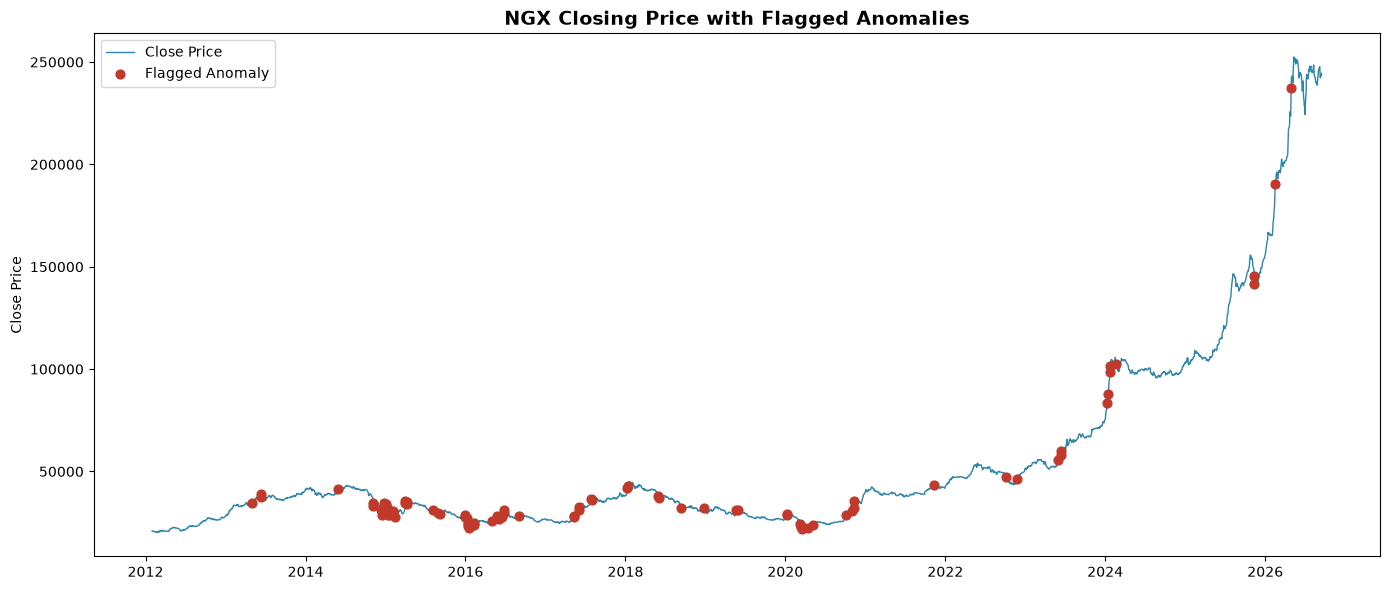

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df["close"], color="#2E86AB", linewidth=1, label="Close Price")

anomalies = df[df["is_anomaly"] == 1]
ax.scatter(anomalies.index, anomalies["close"], color="#C0392B", s=40, zorder=5, label="Flagged Anomaly")

ax.set_title("NGX Closing Price with Flagged Anomalies", fontsize=14, fontweight="bold")
ax.set_ylabel("Close Price")
ax.legend()
plt.tight_layout()
plt.savefig("../visuals/anomalies_flagged.png", dpi=150)
plt.show()

## Top Anomalies by Magnitude

In [6]:
top_anomalies = (
    df[df["is_anomaly"] == 1]
    .assign(abs_return=lambda d: d["daily_return"].abs())
    .sort_values("abs_return", ascending=False)
    .head(15)
)
top_anomalies[["close", "daily_return", "z_score", "is_anomaly_zscore", "is_anomaly_isoforest"]]

,close,daily_return,z_score,is_anomaly_zscore,is_anomaly_isoforest
date,,,,,
2015-04-01,34392.56,0.083123,8.807797,1,1
2020-11-12,35342.46,0.062345,6.586718,1,1
2023-05-30,55745.74,0.052325,5.515690,1,1
2025-11-11,141327.30,-0.050425,-5.467734,1,1
2014-12-24,34428.82,0.050107,5.278634,1,1
2020-10-06,28909.37,0.049168,5.178250,1,1
2020-03-10,24388.66,-0.049084,-5.324353,1,1
2014-12-23,32786.00,0.045074,4.740635,1,1
2026-02-16,190281.56,0.043708,4.594542,1,1


**Takeaway:** Flagged anomalies appear throughout the full sample rather than concentrating in 
a single period, but show a visible increase in frequency from 2023 onward, coinciding with 
the index's near-parabolic rally from ~50,000 to ~250,000. This suggests that periods of rapid 
price appreciation carry more single-day statistical outliers, even when overall volatility 
(as measured by 30-day rolling std dev) has moderated compared to earlier turbulent periods 
like 2015-2016. The three most extreme single-day moves were a **+8.31% surge on 2015-04-01**, 
a **+6.23% gain on 2020-11-12**, and a **-5.47% drop on 2025-11-11** — the latter notably 
occurring while the index was trading near all-time highs (₦141,327), making it the largest 
single-day decline in the dataset and a strong candidate for what a real-time risk monitoring 
system would want to flag immediately.

## Save Final Output (for SQL / dashboard)

In [7]:
df.to_csv("../data/ngx_prices_clean.csv")  # overwrite with anomaly columns added
print("Updated ../data/ngx_prices_clean.csv with anomaly detection columns")
print("This file is now ready to load into SQLite/Power BI (see sql/ and dashboard/)")

Updated ../data/ngx_prices_clean.csv with anomaly detection columns
This file is now ready to load into SQLite/Power BI (see sql/ and dashboard/)
